In [3]:
# Import libraries
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Initialize BigQuery client
client = bigquery.Client(project='abridge-client-prod')
print(f"Connected to project: {client.project}")

print("Libraries imported successfully!")


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Connected to project: abridge-client-prod
Libraries imported successfully!


In [83]:
query0= '''select 
  note_gen_date,
  feedback_tag,
  enc_feedback,
  SUM(enc_feedback) OVER (PARTITION BY note_gen_date) as tot_enc_day
FROM (
select
  date(note_generated_date) as note_gen_date,
  feedback_tag,
  COUNT(DISTINCT encounter_id) as enc_feedback
FROM `abridge-client-prod.dbt_prod.tblEncounter`,
UNNEST (feedback_tags) as feedback_tag
where date(note_generated_date) >= '2024-09-01'
group by 1, 2
)
ORDER BY 1'''
fd_df = client.query(query0).to_dataframe()
fd_df.head(2)


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,note_gen_date,feedback_tag,enc_feedback,tot_enc_day
0,2024-09-01,Repetitive Information,1,18
1,2024-09-01,Wrong Section,4,18


In [79]:
def plot_feedback_tag(fd_df, wanted_feedback_tags):
    fd_df['perc_enc'] = fd_df['enc_feedback']/fd_df['tot_enc_day']
    
    top_feedback_tags_df = fd_df[fd_df['feedback_tag'].isin(wanted_feedback_tags)]

    top_feedback_tags_df.head(2)

    top_feedback_tags_df['perc_enc_7ma'] = top_feedback_tags_df.groupby('feedback_tag')['perc_enc'].transform(
        lambda x: x.rolling(window=7, center=True).mean()
    )

    # Plot with seaborn
    plt.figure(figsize=(14, 8))

    # Original data (lighter lines)
    sns.lineplot(data=top_feedback_tags_df, x='note_gen_date', y='perc_enc', 
                hue='feedback_tag', alpha=0.3, linewidth=1, legend=False)
                

    # 7-day moving average (bold lines)
    sns.lineplot(data=top_feedback_tags_df, x='note_gen_date', y='perc_enc_7ma', 
                hue='feedback_tag', linewidth=2.5)

    plt.xlabel('Date')
    plt.ylabel('Percentage (%)')  
    plt.title('Top Feedback Tags (Over Enc w/ Feedback) Freq Over Time (with 7-day Moving Average)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

/var/folders/td/n93n2yh91jbcsq3gs0bh1wlm0000gp/T/ipykernel_66127/1633945458.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_feedback_tags_df['perc_enc_7ma'] = top_feedback_tags_df.groupby('feedback_tag')['perc_enc'].transform(


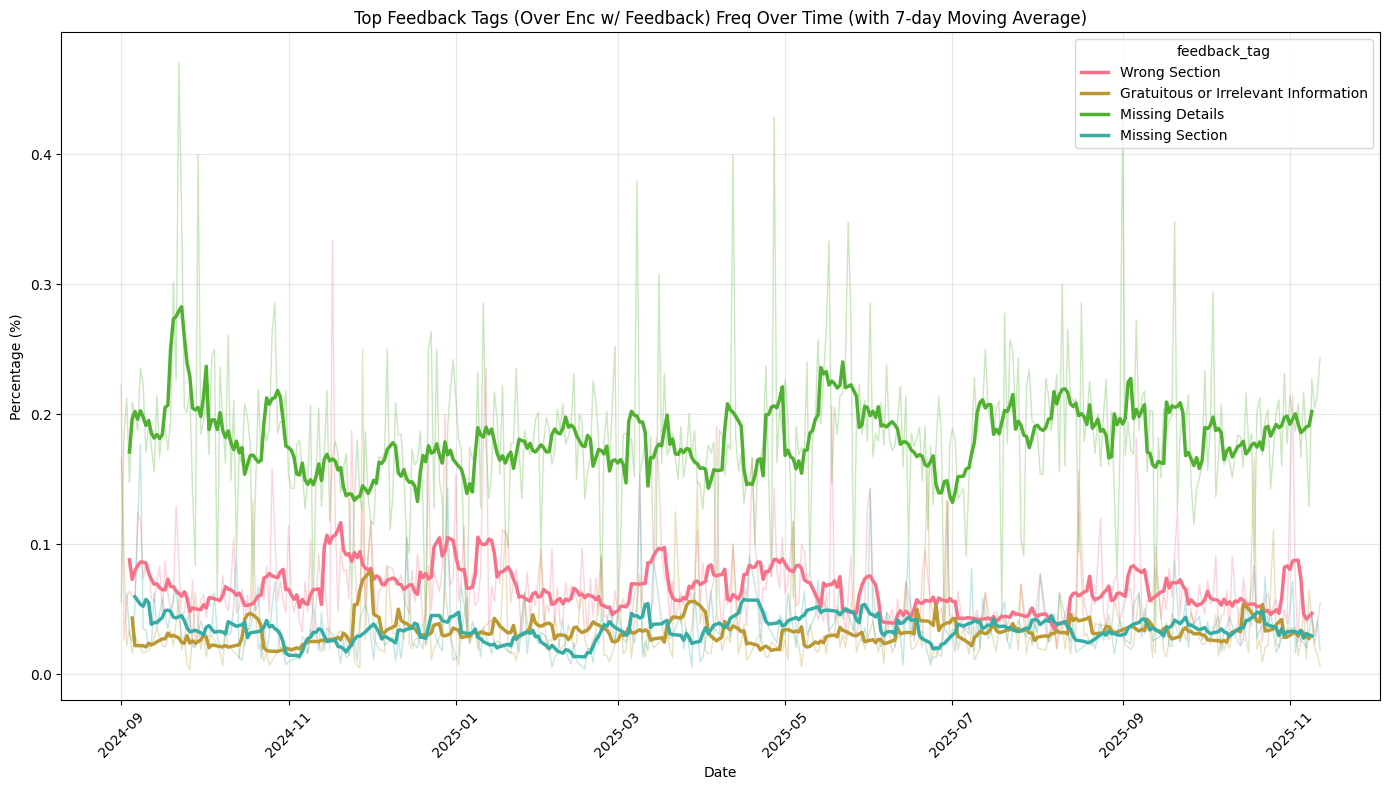

In [84]:
# wanted_feedback_tags = fd_df.groupby('feedback_tag')['enc_feedback'].sum().nlargest(4).index
wanted_feedback_tags = ['Missing Section', 'Missing Details', 'Gratuitous or Irrelevant Information', 'Wrong Section']
plot_feedback_tag(fd_df, wanted_feedback_tags)

In [ ]:
query0= '''
with ft as (
select 
  date(note_generated_date) as note_gen_date,
  feedback_tag, 
  count(distinct encounter_id) as num_enc
FROM `abridge-client-prod.dbt_prod.tblEncounter` ,
UNNEST(feedback_tags) AS feedback_tag
where feedback_tags is not null
group by 1, 2),

enc_day as (
select
  date(note_generated_date) as note_gen_date,
  count(distinct encounter_id) as num_enc_day
FROM `abridge-client-prod.dbt_prod.tblEncounter`
group by 1
)

select
  enc_day.note_gen_date,
  enc_day.num_enc_day,
  ft.feedback_tag,
  ft.num_enc
from enc_day=
inner join ft on enc_day.note_gen_date = ft.note_gen_date
'''
feedback_df = client.query(query0).to_dataframe()

df = feedback_df.copy()


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [58]:
# number of encounters per day
df.head(2)
df['perc_enc'] = df.num_enc/df.num_enc_day
# print(tot_enc)

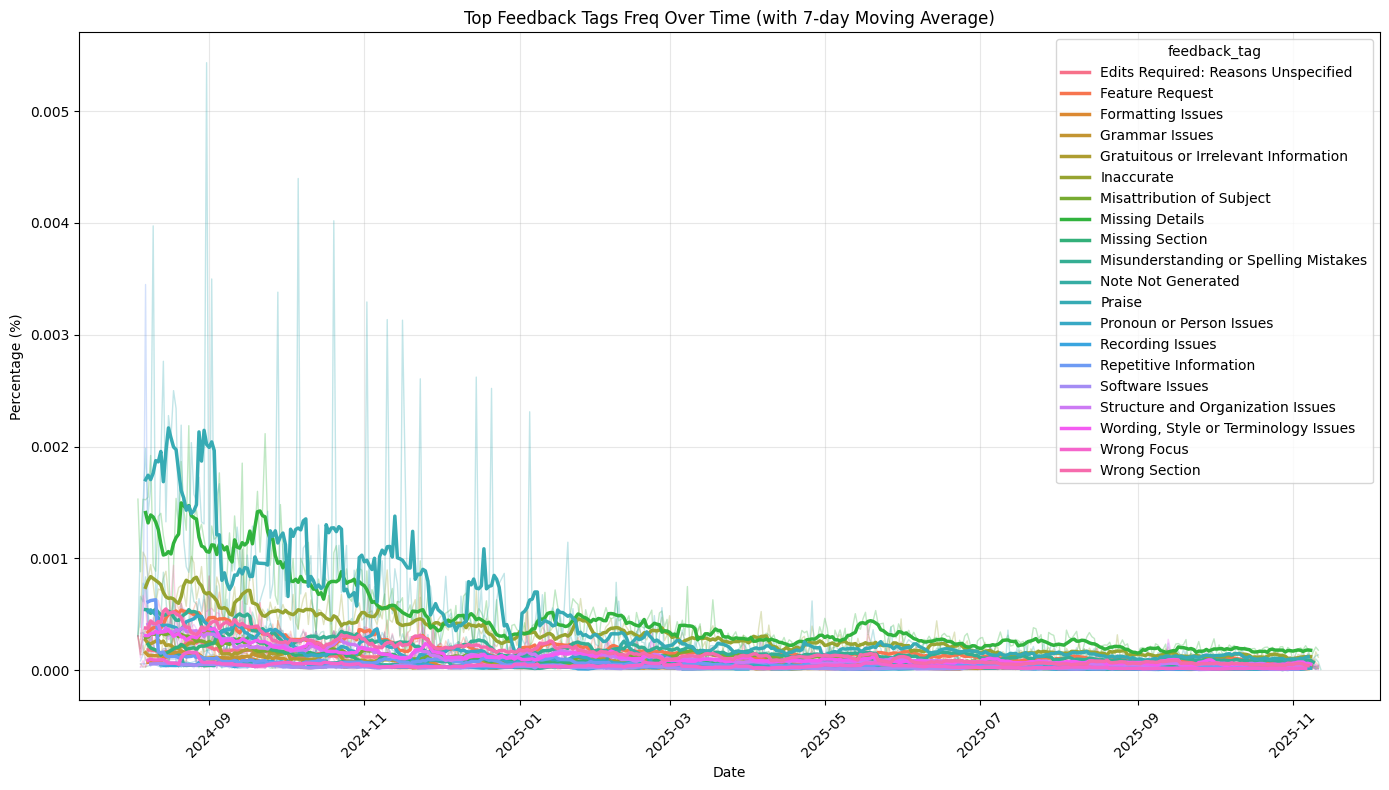

In [63]:
# Get top 6 tags and filter data
top_tags = df.groupby('feedback_tag')['num_enc'].sum().nlargest(20).index
top_merged = df[df['feedback_tag'].isin(top_tags)].copy()

# Convert date to datetime for proper sorting
top_merged['note_gen_date'] = pd.to_datetime(top_merged['note_gen_date'])

# Sort by tag and date, then calculate 7-day moving average using groupby
top_merged = top_merged.sort_values(['feedback_tag', 'note_gen_date'])
top_merged['perc_enc_7ma'] = top_merged.groupby('feedback_tag')['perc_enc'].transform(
    lambda x: x.rolling(window=7, center=True).mean()
)

# Plot with seaborn
plt.figure(figsize=(14, 8))

# Original data (lighter lines)
sns.lineplot(data=top_merged, x='note_gen_date', y='perc_enc', 
             hue='feedback_tag', alpha=0.3, linewidth=1, legend=False)

# 7-day moving average (bold lines)
sns.lineplot(data=top_merged, x='note_gen_date', y='perc_enc_7ma', 
             hue='feedback_tag', linewidth=2.5)

plt.xlabel('Date')
plt.ylabel('Percentage (%)')  
plt.title('Top Feedback Tags Freq Over Time (with 7-day Moving Average)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# look at distribution of tags/encounter 
query0= '''select 
  encounter_id,
  count(feedback_tag) as num_fts
FROM `abridge-client-prod.dbt_prod.tblEncounter` ,
UNNEST(feedback_tags) AS feedback_tag
group by 1'''
ft_df = client.query(query0).to_dataframe()

                           encounter_id  num_fts
0  b21e6a7e-a5d8-4d28-bfc0-ea4e0436f809        5
1  3015dc29-ddcb-4776-bae7-97de8f4b15d4        5


<Figure size 1200x800 with 0 Axes>

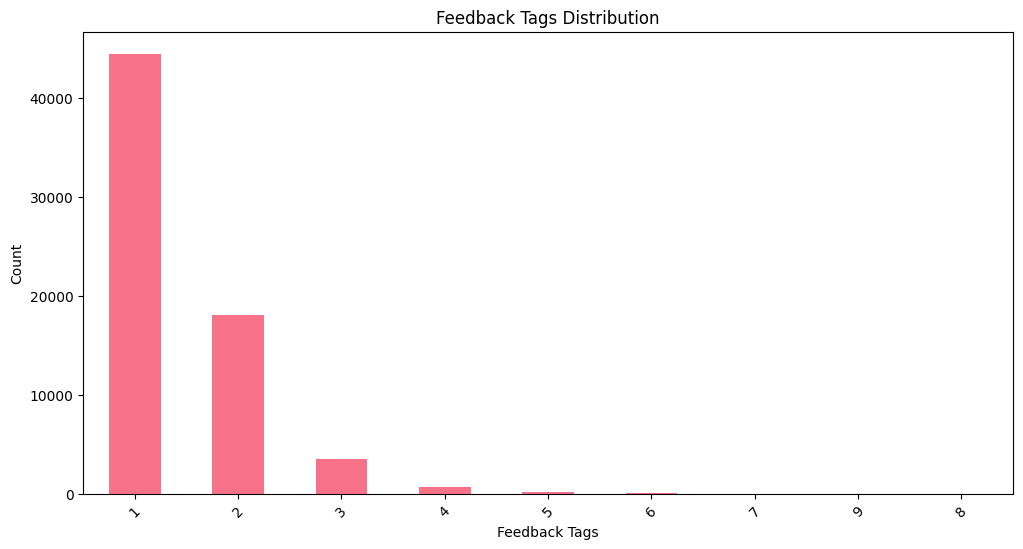

num_fts
1    66.485913
2    27.030863
3     5.192555
4     0.994891
5     0.247976
6     0.041827
7     0.002988
9     0.001494
8     0.001494
Name: proportion, dtype: Float64


In [29]:
print(ft_df.head(2))
# Basic histogram/bar chart of feedback tags
plt.figure(figsize=(12, 8))

# Count the frequency of each feedback tag
tag_counts = ft_df['num_fts'].value_counts()

plt.figure(figsize=(12, 6))
ft_df['num_fts'].value_counts().plot(kind='bar')
plt.title('Feedback Tags Distribution')
plt.xlabel('Feedback Tags')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(ft_df['num_fts'].value_counts(normalize=True) * 100)

## get metadata for encounters

In [ ]:
# look at distribution of tags/encounter 
query0= '''select 
  encounter_id,
  encounter_surface,
  care_setting,
  orgs,
  count(feedback_tag) as num_fts
FROM `abridge-client-prod.dbt_prod.tblEncounter` ,
UNNEST(feedback_tags) AS feedback_tag
group by 1'''
ft_df = client.query(query0).to_dataframe()


BadRequest: 400 SELECT list expression references column encounter_surface which is neither grouped nor aggregated at [3:3]; reason: invalidQuery, location: query, message: SELECT list expression references column encounter_surface which is neither grouped nor aggregated at [3:3]

Location: US
Job ID: 21ae53e5-52e1-46ab-8f12-3deb1c820a16


In [12]:
query_ft_meta = '''select 
  encounter_id,
  encounter_surface,
  care_setting,
  org,
  specialty_note_type,
  appointment_type,
  hpi_style,
  pbap_style,
  pbap_model,
  hpi_model, 
  hpi_format,
  count(distinct ft)  as num_ft
FROM `abridge-client-prod.dbt_prod.tblEncounter`,
UNNEST(feedback_tags) AS ft
where date(note_generated_date) >= '2025-09-01'
group by 1,2,3,4,5,6,7,8,9,10,11'''
ft_meta_df = client.query(query_ft_meta).to_dataframe()
ft_meta_df.head()


/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,encounter_id,encounter_surface,care_setting,org,specialty_note_type,appointment_type,hpi_style,pbap_style,pbap_model,hpi_model,hpi_format,num_ft
0,d620a417-74f2-47d2-a2c4-b04a34b5f06a,copy-paste,None,truecare,behavioral_health_visit,None,concise,concise,cs-v2-pbap_concise_paragraph_vp_5-2.32.0-secti...,cs-v2-hpi_comprehensive_bh_2-2.32.0,bullet,1
1,de53a736-e63b-4e0e-adf0-88bd1e472f1f,copy-paste,None,maimonides,standard,None,comprehensive,comprehensive,cs-v2-pbap_comprehensive_bullets_vp_5-2.44.0-s...,cs-v2-hpi_comprehensive_14-2.44.0-section_post...,paragraph,2
2,9af9d84e-bc3f-4747-af86-9946e9121df6,copy-paste,None,west-michigan-family-medicine,None,None,concise,concise,cs-v2-pbap_concise_bullets_vp_5-2.41.0-section...,cs-v2-hpi_concise_14-2.41.0,paragraph,1
3,a34e7c0c-2a72-491b-808d-8f6367fb730a,inside,inpatient,childrens-healthcare-atlanta,behavioral_health_visit,epic-haiku,comprehensive,concise,cs-v2-pbap_concise_bullets_vp_6-3.5.0-section_...,cs-v2-hpi_comprehensive_bh_2-3.5.0,paragraph,1
4,1fdb6b69-e13d-44f2-af4e-e465abce529e,copy-paste,None,university-of-utah,None,None,concise,comprehensive,cs-v2-pbap_comprehensive_bullets_vp_5-2.43.0-s...,cs-v2-hpi_concise_14-2.43.0,paragraph,1


In [13]:
query_ft = '''select ft
  FROM `abridge-client-prod.dbt_prod.tblEncounter`,
        UNNEST(feedback_tags) AS ft
    group by 1
    '''
ft = client.query(query_ft).to_dataframe()
ft

/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,ft
0,Recording Issues
1,Gratuitous or Irrelevant Information
2,Praise
3,Formatting Issues
4,Wrong Focus
5,Inaccurate
6,Misattribution of Subject
7,Grammar Issues
8,Repetitive Information
9,Transcription Language Error


In [14]:
query_ft_cnt = '''select count(distinct ft) as num_ft
  FROM `abridge-client-prod.dbt_prod.tblEncounter`,
        UNNEST(feedback_tags) AS ft
    '''
count_ft = client.query(query_ft_cnt).to_dataframe()
count_ft

/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,num_ft
0,25


## Correct biases (reviewer level, factor level (care setting, hpi stype etc))

In [31]:
import pandas as pd
import numpy as np
from io import StringIO

def calculate_reviewer_bias_corrected_scores(df: pd.DataFrame, debias_factors: list = None) -> pd.DataFrame:
    """
    Calculates the Note Quality Score (WDS) and then adjusts it to neutralize 
    the bias introduced by the specific doctor/reviewer's historical strictness 
    or tagging preference.

    The bias correction uses the individual doctor's average defect score as 
    the baseline for normalization.
    
    Args:
        csv_data (str): The raw CSV data.
        debias_factors (list): Optional list of columns (e.g., ['care_setting', 'hpi_style']) 
                               to define the peer group. If None, the doctor's own average 
                               is used, effectively correcting against their own history.
    """
    
    # --- 1. DEFINE SEVERITY WEIGHTS ---
    SEVERITY_WEIGHTS = {
        'Inaccurate': 10, 
        'Wrong Focus': 8, 
        'Recording Issues': 6, 
        'EHR Integration Issues': 7, 
        'None': 0, 
        'Software Issues': 9, 
        'Gratuitous or Irrelevant Information': 2, 
        'User Error': 6, 
        'Misattribution of Subject': 9, 
        'Repetitive Information': 5, 
        'Structure and Organization Issues': 5, 
        'Misunderstanding or Spelling Mistakes': 3, 
        'Feature Request': 0, 
        'Missing Section': 9, 
        'Note Not Generated': 10, 
        'Wording, Style or Terminology Issues': 4, 
        'Edits Required: Reasons Unspecified': 5, 
        'Formatting Issues': 3, 
        'Praise': 0, 
        'Slow Note Generation': 1, 
        'Pronoun or Person Issues': 4, 
        'Wrong Section': 5, 
        'Grammar Issues': 2, 
        'Transcription Language Error': 4, 
        'Missing Details': 8
    }


    
    # --- 2. PRE-PROCESSING AND DEFECT SCORE (D_note) ---
    df['feedback_tag'] = df['feedback_tag'].str.strip()
    df['severity_weight'] = df['feedback_tag'].apply(lambda x: SEVERITY_WEIGHTS.get(x, 0))

    # Calculate D_note (Total Defect Score per Note)
    note_scores = df.groupby(['unique_id', 'encounter_id']).agg(
        D_note=('severity_weight', 'sum'),
        D_note_count=('feedback_tag', 'size')
    ).reset_index()

    # Merge note context back in (to preserve columns for later analysis/grouping)
    note_context = df[['encounter_id'] + (debias_factors if debias_factors else [])].drop_duplicates()
    note_scores = pd.merge(note_scores, note_context, on='encounter_id', how='left')

    # Calculate Global Max Defect Score for raw WDS metric
    D_max_practical = sum(w for w in SEVERITY_WEIGHTS.values() if w > 0)
    if D_max_practical == 0: D_max_practical = 1 

    # Calculate Raw Note Quality Score (WDS, based on global D_max)
    note_scores['Raw_Note_Quality_Score'] = (100 * (1 - (note_scores['D_note'] / D_max_practical)))
    
    # --- 3. DURATION QUARTILE BINNING (For complex debiasing) ---
    for col in ['ml_pipeline_duration', 'audio_duration']:
        if col in note_scores.columns:
            # We must use the original dataframe 'df' to ensure accurate quartiles
            # of all recorded times, even if they didn't have tags.
            df_temp = df.copy().dropna(subset=[col])
            
            # Use qcut to assign quartiles (Q1, Q2, Q3, Q4)
            note_scores[f'{col[:2]}_Q'] = pd.qcut(
                df_temp[col], 
                q=4, 
                labels=['Q1', 'Q2', 'Q3', 'Q4'], 
                duplicates='drop'
            ).astype(str)
            # Fill NaNs created by qcut with a placeholder (e.g., 'NA')
            note_scores[f'{col[:2]}_Q'] = note_scores[f'{col[:2]}_Q'].fillna('NA')

    # --- 4. REVIEWER BIAS CORRECTION (Doctor Normalization) ---

    # Define the grouping key for the doctor's average. 
    # If no debias_factors are provided, we group only by 'unique_id'
    # which corrects solely for the doctor's overall strictness/leniency.
    if not debias_factors:
        grouping_cols = ['unique_id']
    else:
        # Group by the doctor ID AND the context (Corrects for context-specific strictness)
        grouping_cols = ['unique_id'] + [c for c in debias_factors if c in note_scores.columns]
        
    
    # Calculate the Doctor's Context-Adjusted Average Defect Score 
    # (The denominator for the final score)
    doctor_avg_defects = note_scores.groupby(grouping_cols)['D_note'].mean().reset_index()
    doctor_avg_defects.rename(columns={'D_note': 'Doc_Avg_Defect_D_note'}, inplace=True)
    
    # Merge the doctor's average defect score back to the encounter-level data
    note_scores = pd.merge(note_scores, doctor_avg_defects, on=grouping_cols, how='left')
    
    # Handle the case where the Doc_Avg_Defect_D_note might be 0 (Doctor has only perfect notes)
    # We set the baseline to 1 in this rare case to avoid division by zero.
    # note_scores['Doc_Avg_Defect_D_note'] = note_scores['Doc_Avg_Defect_D_note'].replace(0, 1)

    # Calculate the FINAL Reviewer Bias Corrected Score
    # This score measures D_note against the Doctor's OWN historical performance (their grading curve).
    note_scores['Reviewer_Bias_Corrected_Score'] = (
        100 * (1 - (note_scores['D_note'] / note_scores['Doc_Avg_Defect_D_note']))
    )
    
    # Clip the score. Scores below 0 indicate a note that is worse than that doctor's average.
    note_scores['Reviewer_Bias_Corrected_Score'] = np.clip(note_scores['Reviewer_Bias_Corrected_Score'], -1000, 100)


    # --- 5. FINAL OUTPUT SELECTION ---
    output_cols = ['unique_id', 'encounter_id', 'D_note', 'Doc_Avg_Defect_D_note', 
                   'Raw_Note_Quality_Score', 'Reviewer_Bias_Corrected_Score']
    
    # Add grouping columns to the final output for analysis
    for col in grouping_cols:
         if col not in output_cols:
             output_cols.append(col)

    return note_scores[output_cols].sort_values('Reviewer_Bias_Corrected_Score', ascending=False)

# --- EXECUTION ---
# Use the uploaded content ID to load the data

query = '''select * from dbt_mchen.tbl_qs_from_tags 
'''
input_df = client.query(query).to_dataframe()
# print(basic_corrected_df.to_markdown(index=False))    
# only debias for the doctor's own history
basic_corrected_df = calculate_reviewer_bias_corrected_scores(input_df, debias_factors=None)


complex_corrected_df = calculate_reviewer_bias_corrected_scores(input_df, debias_factors=['care_setting', 'hpi_style'])
# print(complex_corrected_df.to_markdown(index=False))



/Users/maggie/projects/abridge-personal-analysis/venv312/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [32]:

basic_corrected_df.head(2)





NameError: name 'basic_corrected_df' is not defined

In [2]:
input_df = client.query(query).to_dataframe()

input_df.shape

NameError: name 'client' is not defined

#### compute review bias corrected score by different factors

In [111]:
# Analyze Reviewer_Bias_Corrected_Score by factors
factors = ['care_setting', 'hpi_style', 'pbap_style', 'hpi_format', 'ml_pipeline_duration', 'audio_duration']
# 'pbap_model', 'hpi_model',

# Merge basic_corrected_df with input_df to get the factors
# Get unique encounter_id and factor columns from input_df
factor_cols = ['encounter_id'] + [f for f in factors if f in input_df.columns]
input_factors = input_df[factor_cols].drop_duplicates(subset=['encounter_id'])

# Merge with basic_corrected_df
analysis_df = basic_corrected_df.merge(input_factors, on='encounter_id', how='left')

# For duration columns, create bins for better visualization
if 'ml_pipeline_duration' in analysis_df.columns:
    analysis_df['ml_pipeline_duration_binned'] = pd.qcut(
        analysis_df['ml_pipeline_duration'].dropna(), 
        q=4, 
        labels=['Q1 (Fastest)', 'Q2', 'Q3', 'Q4 (Slowest)'], 
        duplicates='drop'
    )
    analysis_df['ml_pipeline_duration_binned'] = analysis_df['ml_pipeline_duration_binned'].astype(str)

if 'audio_duration' in analysis_df.columns:
    analysis_df['audio_duration_binned'] = pd.qcut(
        analysis_df['audio_duration'].dropna(), 
        q=4, 
        labels=['Q1 (Shortest)', 'Q2', 'Q3', 'Q4 (Longest)'], 
        duplicates='drop'
    )
    analysis_df['audio_duration_binned'] = analysis_df['audio_duration_binned'].astype(str)

# Calculate summary statistics for each factor
print("=" * 80)
print("SUMMARY STATISTICS BY FACTOR")
print("=" * 80)

for factor in factors:
    if factor not in analysis_df.columns:
        print(f"\n⚠️  Factor '{factor}' not found in data. Skipping...")
        continue
    
    # Use binned version for duration columns
    if factor == 'ml_pipeline_duration' and 'ml_pipeline_duration_binned' in analysis_df.columns:
        factor_col = 'ml_pipeline_duration_binned'
    elif factor == 'audio_duration' and 'audio_duration_binned' in analysis_df.columns:
        factor_col = 'audio_duration_binned'
    else:
        factor_col = factor
    
    # Calculate statistics
    stats = analysis_df.groupby(factor_col)['Reviewer_Bias_Corrected_Score'].agg([
        ('mean', 'mean'),
        ('median', 'median'),
        ('p25', lambda x: x.quantile(0.25)),
        ('p75', lambda x: x.quantile(0.75)),
        ('count', 'count'),
        ('std', 'std')
    ]).round(2)
    
    
    print(f"\n{factor.upper()}:")
    print(stats)
    print("-" * 80)


SUMMARY STATISTICS BY FACTOR

CARE_SETTING:
                      mean  median    p25    p75  count    std
care_setting                                                  
emergency             0.29    0.00 -25.96  34.81    827  53.20
hospital_outpatient -10.36    0.00 -56.62  33.57     51  71.83
inpatient             0.74    0.00 -28.57  40.95    195  64.29
outpatient            1.46    5.08 -26.51  44.89  45935  85.22
--------------------------------------------------------------------------------

HPI_STYLE:
               mean  median    p25    p75  count     std
hpi_style                                               
comprehensive  1.29    3.91 -25.49  43.08  43898   79.18
concise        2.63    4.26 -23.53  50.87  21414  100.28
--------------------------------------------------------------------------------

PBAP_STYLE:
               mean  median    p25    p75  count    std
pbap_style                                             
comprehensive  0.59    5.81 -26.67  45.31  20655  8

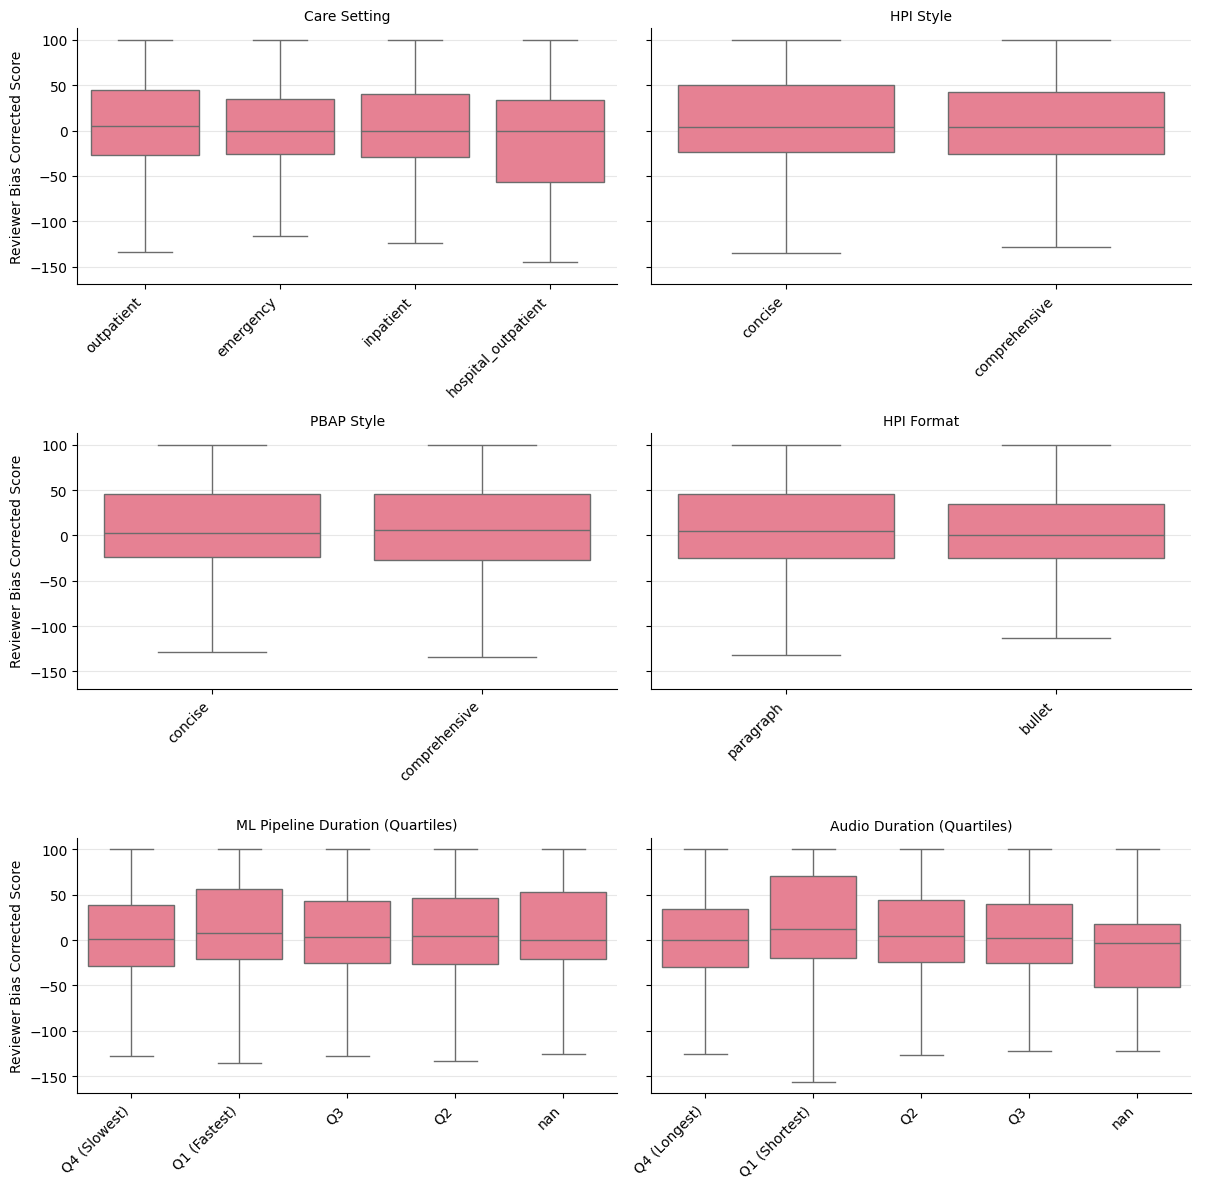

In [113]:
# Create boxplots for factors_to_plot using analysis_df
# Filter factors that exist in analysis_df
factors_to_plot = ['care_setting', 'hpi_style', 'pbap_style', 'hpi_format', 'ml_pipeline_duration_binned', 'audio_duration_binned']

# Create labels for each factor
factor_labels = {
    'care_setting': 'Care Setting',
    'hpi_style': 'HPI Style',
    'pbap_style': 'PBAP Style',
    'hpi_format': 'HPI Format',
    'ml_pipeline_duration_binned': 'ML Pipeline Duration (Quartiles)',
    'audio_duration_binned': 'Audio Duration (Quartiles)'
}

# Reshape data to long format using list comprehension
plot_data_list = [
    analysis_df[[factor, 'Reviewer_Bias_Corrected_Score']]
    .dropna(subset=[factor, 'Reviewer_Bias_Corrected_Score'])
    .rename(columns={factor: 'factor_value'})
    .assign(factor_name=factor_labels.get(factor, factor.replace('_', ' ').title()))
    for factor in factors_to_plot
]

plot_data_long = pd.concat(plot_data_list, ignore_index=True)

# Create boxplots using seaborn catplot (no for loop needed)
g = sns.catplot(
    data=plot_data_long,
    x='factor_value',
    y='Reviewer_Bias_Corrected_Score',
    col='factor_name',
    kind='box',
    col_wrap=2,
    height=4,
    aspect=1.5,
    sharex=False,
    sharey=True,
    showfliers=False  # Remove outliers from boxplots
)

# Customize plots using vectorized operations
g.set_axis_labels('', 'Reviewer Bias Corrected Score')
g.set_titles('{col_name}')
g.set_xticklabels(rotation=45, ha='right')

# Add grid to all axes at once
[ax.grid(True, alpha=0.3, axis='y') for ax in g.axes.flat]

plt.tight_layout()
plt.show()


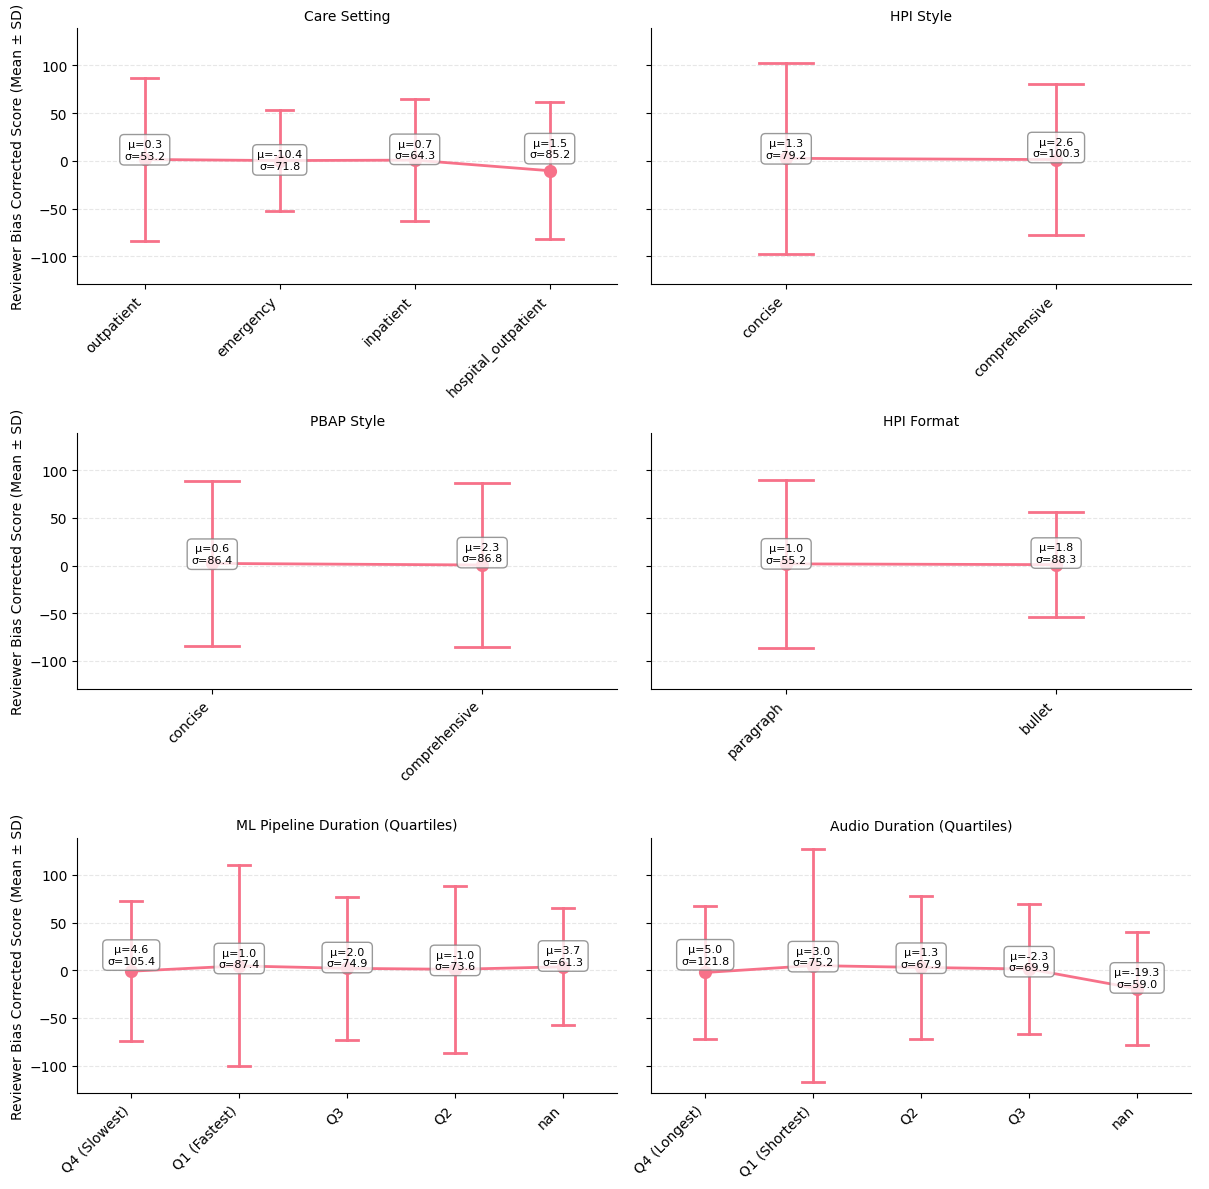

In [112]:
# Create separate plot showing mean and standard deviation by factors
# Calculate mean and std for each factor
stats_df = plot_data_long.groupby(['factor_name', 'factor_value'])['Reviewer_Bias_Corrected_Score'].agg([
    ('mean', 'mean'),
    ('std', 'std'),
    ('count', 'count')
]).reset_index()

# Create point plot with error bars showing mean ± std
g2 = sns.catplot(
    data=plot_data_long,
    x='factor_value',
    y='Reviewer_Bias_Corrected_Score',
    col='factor_name',
    kind='point',
    col_wrap=2,
    height=4,
    aspect=1.5,
    sharex=False,
    sharey=True,
    errorbar='sd',  # Show standard deviation as error bars
    capsize=0.2,
    markers='o',
    linestyles='-',
    linewidth=2,
    markersize=8
)

# Customize plots
g2.set_axis_labels('', 'Reviewer Bias Corrected Score (Mean ± SD)')
g2.set_titles('{col_name}')
g2.set_xticklabels(rotation=45, ha='right')

# Add grid and mean value annotations
for ax, factor_name in zip(g2.axes.flat, g2.col_names):
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    # Add mean value text annotations
    factor_stats = stats_df[stats_df['factor_name'] == factor_name].sort_values('factor_value')
    for idx, (_, row) in enumerate(factor_stats.iterrows()):
        ax.text(
            idx, row['mean'], 
            f"μ={row['mean']:.1f}\nσ={row['std']:.1f}", 
            ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='gray')
        )

plt.tight_layout()
plt.show()


#### testing

In [ ]:
# Testing the score computation
input_df_test = input_df.copy()


    
    # --- 2. PRE-PROCESSING AND DEFECT SCORE (D_note) ---
input_df_test['feedback_tag'] = input_df_test['feedback_tag'].str.strip()
input_df_test['severity_weight'] = input_df_test['feedback_tag'].apply(lambda x: SEVERITY_WEIGHTS.get(x, 0))

    # Calculate D_note (Total Defect Score per Note)
note_scores = input_df_test.groupby(['unique_id', 'encounter_id']).agg(
        D_note=('severity_weight', 'sum'),
        D_note_count=('feedback_tag', 'size')
    ).reset_index()

debias_factors = None    
# Merge note context back in (to preserve columns for later analysis/grouping)
note_context = input_df_test[['encounter_id'] + (debias_factors if debias_factors else [])].drop_duplicates()
note_scores = pd.merge(note_scores, note_context, on='encounter_id', how='left')

grouping_cols = ['unique_id']

doctor_avg_defects = note_scores.groupby(grouping_cols)['D_note'].mean().reset_index()
doctor_avg_defects.rename(columns={'D_note': 'Doc_Avg_Defect_D_note'}, inplace=True)
    
# Merge the doctor's average defect score back to the encounter-level data
note_scores = pd.merge(note_scores, doctor_avg_defects, on=grouping_cols, how='left')
    
# Handle the case where the Doc_Avg_Defect_D_note might be 0 (Doctor has only perfect notes)
# We set the baseline to 1 in this rare case to avoid division by zero.
note_scores['Doc_Avg_Defect_D_note'] = note_scores['Doc_Avg_Defect_D_note'].replace(0, 1)
print(note_scores['Doc_Avg_Defect_D_note'].min())

print(note_scores.head(2))

# Calculate the FINAL Reviewer Bias Corrected Score
# This score measures D_note against the Doctor's OWN historical performance (their grading curve).
note_scores['Reviewer_Bias_Corrected_Score'] = (
        100 * (1 - (note_scores['D_note'] / note_scores['Doc_Avg_Defect_D_note']))
    )
    
print(note_scores['Reviewer_Bias_Corrected_Score'].min())    
print(note_scores['Reviewer_Bias_Corrected_Score'].max())    
    # # Clip the score. Scores below 0 indicate a note that is worse than that doctor's average.
    # note_scores['Reviewer_Bias_Corrected_Score'] = np.clip(note_scores['Reviewer_Bias_Corrected_Score'], -1000, 100)


    # # --- 5. FINAL OUTPUT SELECTION ---
    # output_cols = ['unique_id', 'encounter_id', 'D_note', 'Doc_Avg_Defect_D_note', 
    #                'Raw_Note_Quality_Score', 'Reviewer_Bias_Corrected_Score']
    



0.08287292817679558
                              unique_id                          encounter_id  \
0  abridge_046OVaRHgaXxw5JkUYrer55fkZp2  692d8074-846c-448c-83cf-f957a1cd11e4   
1  abridge_0827nT8bFoSqh6jF29ClUdUViE23  0c79cf12-88c4-4a82-8247-002ea0dd1eff   

   D_note  D_note_count  Doc_Avg_Defect_D_note  
0      10             1                   10.0  
1       0             1                    1.0  
-18000.0
100.0


#### end of testing

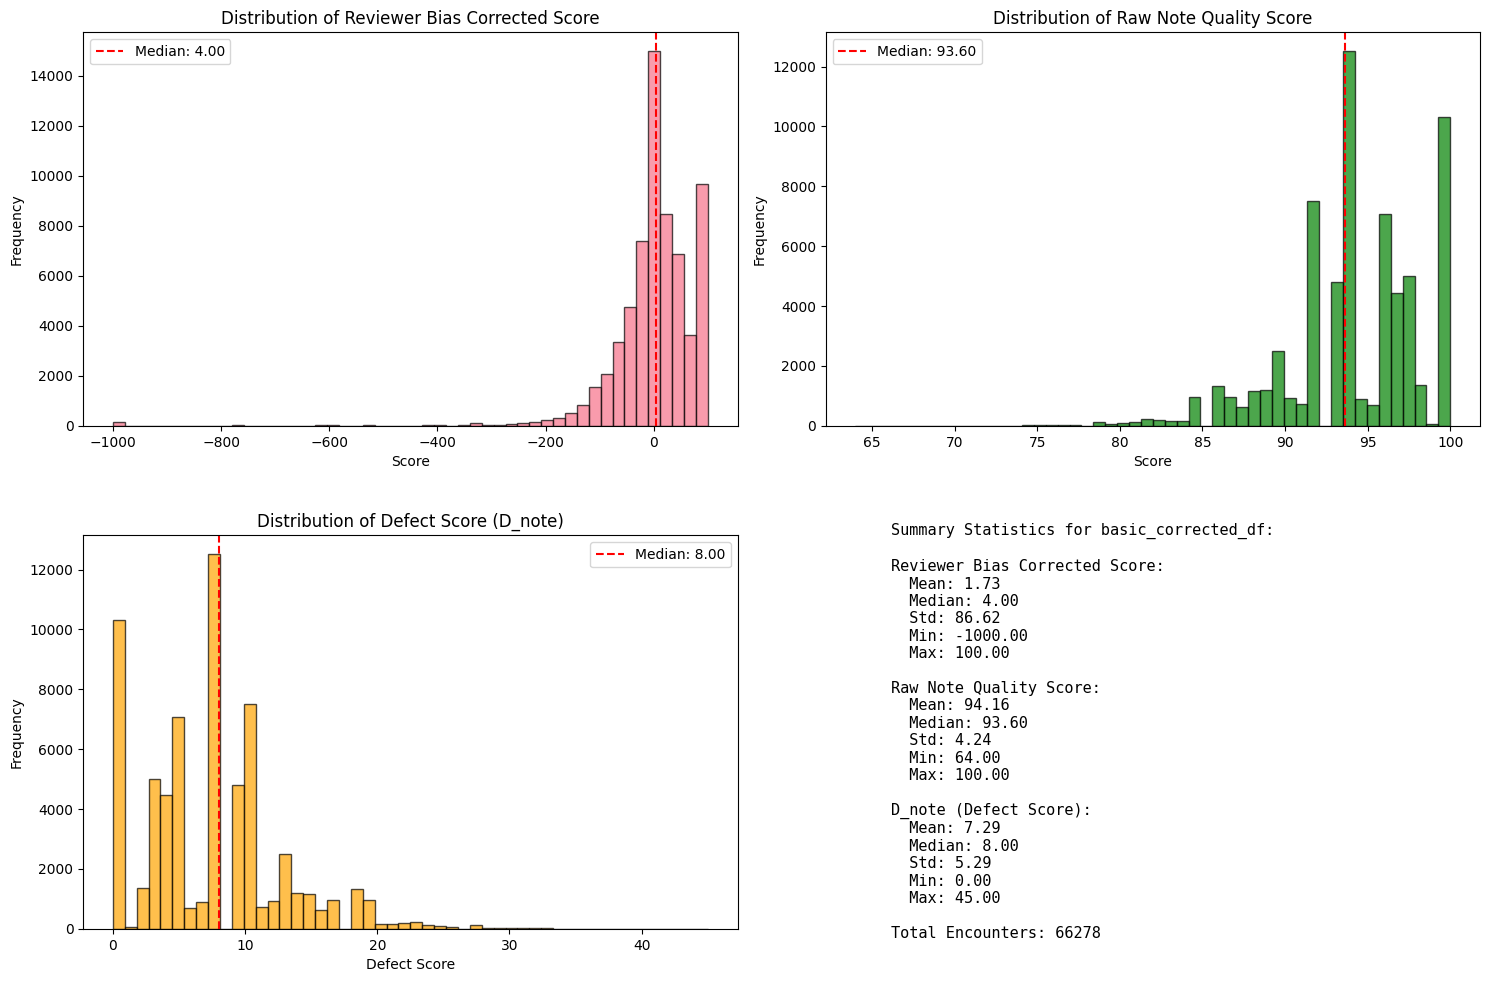

In [84]:
# Plot histograms for basic_corrected_df scores
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram for Reviewer_Bias_Corrected_Score
axes[0, 0].hist(basic_corrected_df['Reviewer_Bias_Corrected_Score'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Reviewer Bias Corrected Score')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(basic_corrected_df['Reviewer_Bias_Corrected_Score'].median(), 
                    color='red', linestyle='--', label=f"Median: {basic_corrected_df['Reviewer_Bias_Corrected_Score'].median():.2f}")
axes[0, 0].legend()

# Histogram for Raw_Note_Quality_Score
axes[0, 1].hist(basic_corrected_df['Raw_Note_Quality_Score'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 1].set_title('Distribution of Raw Note Quality Score')
axes[0, 1].set_xlabel('Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(basic_corrected_df['Raw_Note_Quality_Score'].median(), 
                    color='red', linestyle='--', label=f"Median: {basic_corrected_df['Raw_Note_Quality_Score'].median():.2f}")
axes[0, 1].legend()

# Histogram for D_note (Defect Score)
axes[1, 0].hist(basic_corrected_df['D_note'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Distribution of Defect Score (D_note)')
axes[1, 0].set_xlabel('Defect Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].axvline(basic_corrected_df['D_note'].median(), 
                    color='red', linestyle='--', label=f"Median: {basic_corrected_df['D_note'].median():.2f}")
axes[1, 0].legend()

# Summary statistics
axes[1, 1].axis('off')
summary_text = f"""
Summary Statistics for basic_corrected_df:

Reviewer Bias Corrected Score:
  Mean: {basic_corrected_df['Reviewer_Bias_Corrected_Score'].mean():.2f}
  Median: {basic_corrected_df['Reviewer_Bias_Corrected_Score'].median():.2f}
  Std: {basic_corrected_df['Reviewer_Bias_Corrected_Score'].std():.2f}
  Min: {basic_corrected_df['Reviewer_Bias_Corrected_Score'].min():.2f}
  Max: {basic_corrected_df['Reviewer_Bias_Corrected_Score'].max():.2f}

Raw Note Quality Score:
  Mean: {basic_corrected_df['Raw_Note_Quality_Score'].mean():.2f}
  Median: {basic_corrected_df['Raw_Note_Quality_Score'].median():.2f}
  Std: {basic_corrected_df['Raw_Note_Quality_Score'].std():.2f}
  Min: {basic_corrected_df['Raw_Note_Quality_Score'].min():.2f}
  Max: {basic_corrected_df['Raw_Note_Quality_Score'].max():.2f}

D_note (Defect Score):
  Mean: {basic_corrected_df['D_note'].mean():.2f}
  Median: {basic_corrected_df['D_note'].median():.2f}
  Std: {basic_corrected_df['D_note'].std():.2f}
  Min: {basic_corrected_df['D_note'].min():.2f}
  Max: {basic_corrected_df['D_note'].max():.2f}

Total Encounters: {len(basic_corrected_df)}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center', family='monospace')

plt.tight_layout()
plt.show()


In [ ]:
 
analysis_df.head(2)

,unique_id,encounter_id,D_note,Doc_Avg_Defect_D_note,Raw_Note_Quality_Score,Reviewer_Bias_Corrected_Score,care_setting,hpi_style,pbap_style,pbap_model,hpi_model,hpi_format,ml_pipeline_duration,audio_duration,ml_pipeline_duration_binned,audio_duration_binned
0,kp_nuid_B338997,18657804-4ffd-40ed-b74f-fa6e8055da49,0,7.866667,100.0,100.0,None,concise,concise,gpt-4-0613_bullet_10,gpt-4-0314_concise_6,paragraph,0.95,27.0392,Q4 (Slowest),Q4 (Longest)
1,fhir_ser_epL3fPt968UUKHx5YjjVR81fLwDILzadyLxqk...,85ce7349-fa4f-470a-b65d-744366ac5949,0,5.312500,100.0,100.0,outpatient,comprehensive,concise,cs-v2-pbap_concise_paragraph_vp_4-2.22.1-secti...,cs-v2-hpi_comprehensive_bh_2-2.22.1,paragraph,1.25,45.1024,Q4 (Slowest),Q4 (Longest)
